# Лабараторная работа 1. CNN

### Распознование марки автомобиля по фотографии (Audi, BMW, Mercedes, Toyota)

### Процесс обработки данных:
1. **Аугментация** - все изображения аугментируются на этапе загрузки
2. **Сохранение в HDF5** - аугментированные данные сохраняются в augmented_data.h5
3. **Обучение** - модели обучаются на уже подготовленных данных без дополнительных предварительных обработок

**Преимущества:**
- ⚡ Ускорение обучения (нет повторных аугментаций)
- 💾 Экономия памяти (данные в HDF5)
- 🔄 Воспроизводимость (один раз обработанные данные)

In [12]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, models
from torchvision.transforms import v2 as T2
from tqdm.auto import tqdm
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060


In [14]:
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True

In [15]:
DATA_DIR = "data"
BATCH_SIZE = 128

In [ ]:
train_transforms = T2.Compose([
    T2.Resize((224,224)),
    T2.RandomHorizontalFlip(p=0.5),
    T2.RandomRotation(10),         
    T2.ColorJitter(0.1,0.1,0.1,0.05),
    T2.ToTensor(),
    T2.Normalize([0.485,0.456,0.406],
                 [0.229,0.224,0.225])
])

val_test_transforms = T2.Compose([
    T2.Resize((224,224)),
    T2.ToTensor(),
    T2.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
import h5py
from PIL import Image
import numpy as np

temp_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"))
class_names = temp_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")

In [ ]:
def create_augmented_datasets_hdf5(data_dir, output_file="augmented_data.h5", num_augments=4):
    if os.path.exists(output_file):
        print(f"Файл {output_file} уже существует, пропускаем создание")
        return
    
    print(f"Создание аугментированного датасета в {output_file}...")
    
    with h5py.File(output_file, 'w') as f:
        for split in ['train', 'val', 'test']:
            print(f"\nОбработка {split} набора...")
            
            split_dir = os.path.join(data_dir, split)
            dataset = datasets.ImageFolder(split_dir)
            
            n_original = len(dataset)
            n_augments = num_augments if split == 'train' else 1
            n_total = n_original * n_augments
            
            grp = f.create_group(split)
            imgs_dset = grp.create_dataset('images', shape=(n_total, 224, 224, 3), dtype=np.uint8)
            labels_dset = grp.create_dataset('labels', shape=(n_total,), dtype=np.int32)
            
            idx = 0
            
            if split == 'train':
                transforms = train_transforms
            else:
                transforms = val_test_transforms
            
            for img_idx, (img_path, label) in enumerate(tqdm(dataset.samples, desc=f"{split}")):
                with Image.open(img_path) as img:
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    
                    for aug_idx in range(n_augments):
                        augmented = transforms(img)
                        img_array = (augmented.numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
                        
                        imgs_dset[idx] = img_array
                        labels_dset[idx] = label
                        idx += 1
            
            print(f"{split}: сохранено {idx} изображений")
    
    print(f"\nАугментированные данные сохранены в {output_file}")

create_augmented_datasets_hdf5(DATA_DIR, "augmented_data.h5", num_augments=4)

In [ ]:
class HDF5Dataset(torch.utils.data.Dataset):
    def __init__(self, h5_file, split='train'):
        self.h5_file = h5_file
        self.split = split
        
        with h5py.File(h5_file, 'r') as f:
            self.length = f[split]['images'].shape[0]
    
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        with h5py.File(self.h5_file, 'r') as f:
            img = f[self.split]['images'][idx]
            label = f[self.split]['labels'][idx]
        
        img = torch.from_numpy(img).float() / 255.0
        img = img.permute(2, 0, 1)
        
        img = T2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(img)
        
        return img, label

print("Загрузка данных из HDF5...")
train_dataset = HDF5Dataset("augmented_data.h5", split='train')
val_dataset = HDF5Dataset("augmented_data.h5", split='val')
test_dataset = HDF5Dataset("augmented_data.h5", split='test')

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Classes: ['audi', 'bmw', 'mercedes-benz', 'toyota']


In [ ]:
with h5py.File("augmented_data.h5", 'r') as f:
    targets = f['train']['labels'][:]

class_counts = Counter(targets)
num_samples = sum(class_counts.values())
num_classes = len(class_counts)

class_weights = [num_samples / (num_classes * class_counts[i]) for i in range(num_classes)]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class weights: [0.6928238039673279, 0.753489847715736, 1.380813953488372, 1.9791666666666667]


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"DataLoaders созданы. Batch size: {BATCH_SIZE}")

In [20]:
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=25, patience=5):
    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    scaler = GradScaler()
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    patience_counter = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")

        for phase in ["train","val"]:
            model.train() if phase=="train" else model.eval()
            loader = train_loader if phase=="train" else val_loader

            running_loss = 0.0
            running_corrects = 0
            loop = tqdm(loader, desc=phase, leave=False)

            for inputs, labels in loop:
                inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=="train"):
                    with autocast(device_type=device.type):
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        _, preds = torch.max(outputs, 1)

                    if phase=="train":
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)
                loop.set_postfix(loss=f"{loss.item():.4f}")

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = running_corrects.double() / len(loader.dataset)

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            print(f"{phase} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase=="val":
                scheduler.step(epoch_acc)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f"Early stopping at epoch {epoch+1}")
                        model.load_state_dict(best_model_wts)
                        print(f"Best Val Accuracy: {best_acc:.4f}")
                        return model, history

    model.load_state_dict(best_model_wts)
    print(f"\nBest Val Accuracy: {best_acc:.4f}")
    return model, history

##### Архитектура 1

In [21]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [ ]:
model1 = SimpleCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model1.parameters(), lr=0.001)

model1, history1 = train_model(model1, criterion, optimizer, train_loader, val_loader, num_epochs=100, patience=15)


Epoch [1/1000]


train Loss: 1.4297 | Acc: 0.2766


val Loss: 1.3979 | Acc: 0.1709

Epoch [2/1000]


train Loss: 1.3878 | Acc: 0.2981


val Loss: 1.4312 | Acc: 0.2318

Epoch [3/1000]


...

train Loss: 1.2225 | Acc: 0.4126


val Loss: 1.6298 | Acc: 0.2102

Epoch [14/1000]


train Loss: 1.2107 | Acc: 0.4303


val Loss: 1.2682 | Acc: 0.4047

Epoch [15/1000]


KeyboardInterrupt: 

##### Архитектура 2

In [ ]:
class BetterCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [ ]:
model2 = BetterCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model2.parameters(), lr=0.001)

model2, history2 = train_model(model2, criterion, optimizer, train_loader, val_loader, num_epochs=100, patience=15)


Epoch [1/50]


train:   0%|          | 0/19 [00:00<?, ?it/s]

train Loss: 1.3888 | Acc: 0.2615


val Loss: 1.3641 | Acc: 0.3065

Epoch [2/50]


train Loss: 1.3704 | Acc: 0.3301


...

val Loss: 1.2402 | Acc: 0.4283

Epoch [21/50]


train Loss: 1.1464 | Acc: 0.4737


val Loss: 1.3341 | Acc: 0.3635

Epoch [22/50]


train Loss: 1.1402 | Acc: 0.4745


val Loss: 1.2661 | Acc: 0.3949
Early stopping at epoch 22
Best Val Accuracy: 0.4499


##### Архитектура 3

In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, max(channels // reduction, 1))
        self.fc2 = nn.Linear(max(channels // reduction, 1), channels)
    
    def forward(self, x):
        batch, channels, height, width = x.size()
        squeeze = x.mean((2, 3))
        excitation = torch.relu(self.fc1(squeeze))
        excitation = torch.sigmoid(self.fc2(excitation))
        excitation = excitation.view(batch, channels, 1, 1)
        return x * excitation

class DeepCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            SEBlock(32),
            nn.MaxPool2d(2),
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            SEBlock(64),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            SEBlock(128),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
        )
        
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [ ]:
model3 = DeepCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model3.parameters(), lr=0.001)

model3, history3 = train_model(model3, criterion, optimizer, train_loader, val_loader, num_epochs=100, patience=15)


Epoch [1/50]


train:   0%|          | 0/19 [00:00<?, ?it/s]

train Loss: 1.3871 | Acc: 0.2619


val Loss: 1.3411 | Acc: 0.3635

Epoch [2/50]


train Loss: 1.3607 | Acc: 0.2985


...

val Loss: 1.3207 | Acc: 0.3615

Epoch [11/50]


train Loss: 1.3002 | Acc: 0.3764


val Loss: 1.3879 | Acc: 0.2672

Epoch [12/50]


train Loss: 1.2917 | Acc: 0.3832


val Loss: 1.3495 | Acc: 0.3477
Early stopping at epoch 12
Best Val Accuracy: 0.3772


##### Transfer Learning (ResNet18)

In [ ]:
model_tl = models.resnet50(weights="IMAGENET1K_V1")

for param in model_tl.layer1.parameters():
    param.requires_grad = False
for param in model_tl.layer2.parameters():
    param.requires_grad = False

num_features = model_tl.fc.in_features
model_tl.fc = nn.Linear(num_features, num_classes)

model_tl = model_tl.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model_tl.parameters(), lr=0.0001)

model_tl, history_tl = train_model(model_tl, criterion, optimizer, train_loader, val_loader, num_epochs=15, patience=5)


Epoch [1/15]


train Loss: 0.9450 | Acc: 0.6000


val Loss: 0.5130 | Acc: 0.8114

Epoch [2/15]


train Loss: 0.2885 | Acc: 0.9002


val Loss: 0.3435 | Acc: 0.8978

Epoch [3/15]


...

val Loss: 0.2183 | Acc: 0.9430

Epoch [14/15]


train Loss: 0.0083 | Acc: 0.9975


val Loss: 0.2537 | Acc: 0.9273

Epoch [15/15]


train Loss: 0.0120 | Acc: 0.9962


val Loss: 0.2928 | Acc: 0.9214

Best Val Accuracy: 0.9430


In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title(f"{title} Loss")
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="train")
    plt.plot(history["val_acc"], label="val")
    plt.title(f"{title} Accuracy")
    plt.legend()
    
    plt.show()

In [ ]:
def evaluate_on_test(model, model_name="Model"):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\n{model_name} Test Accuracy: {accuracy:.4f}\n")
    
    print("Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    
    return accuracy

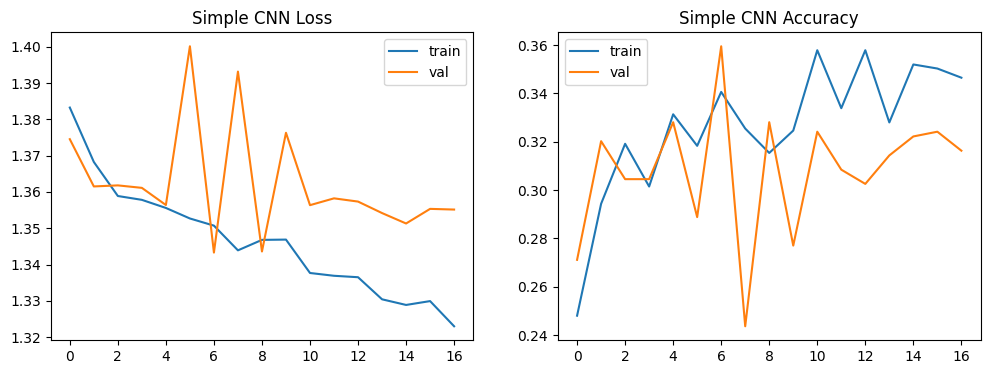

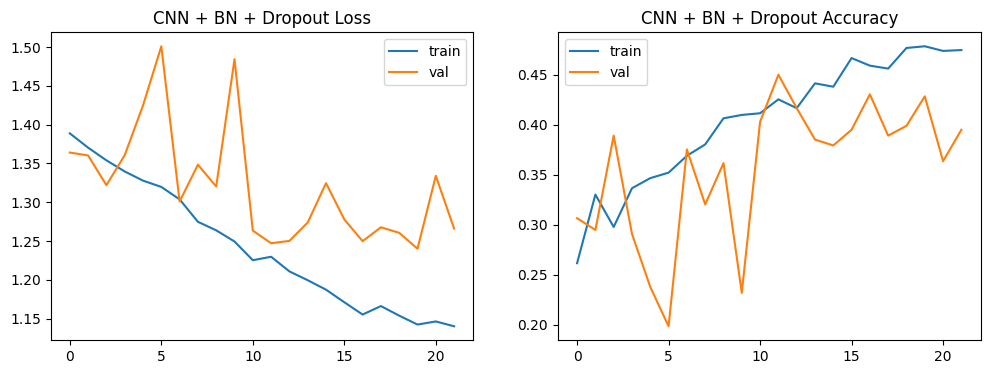

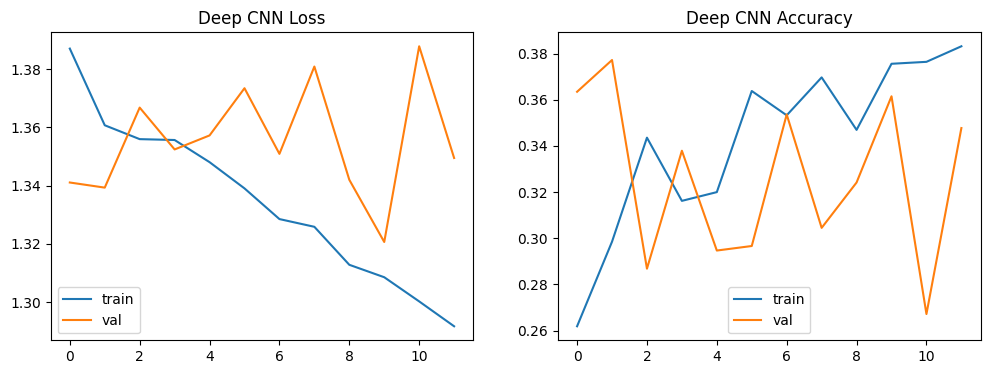

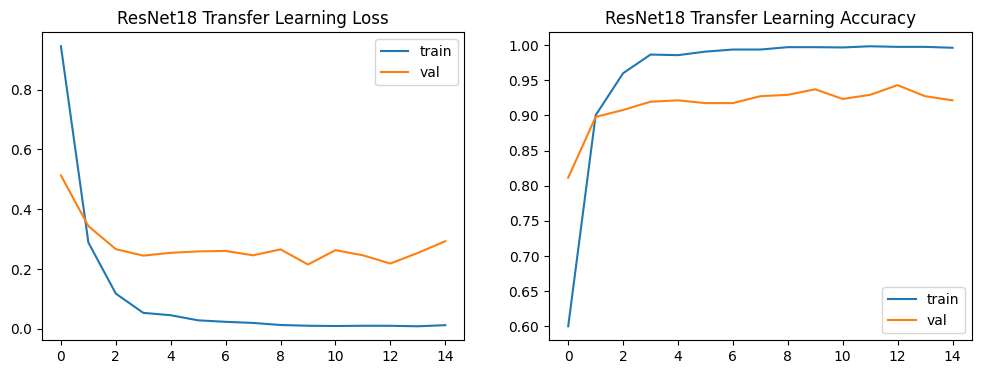

In [ ]:
plot_history(history1, "Simple CNN")
plot_history(history2, "CNN + BN + Dropout")
plot_history(history3, "Deep CNN")
plot_history(history_tl, "ResNet18 Transfer Learning")


Simple CNN Test Accuracy: 0.3483

Classification Report:

               precision    recall  f1-score   support

         audi       0.42      0.54      0.47       184
          bmw       0.47      0.21      0.29       169
mercedes-benz       0.26      0.39      0.31        93
       toyota       0.10      0.09      0.10        65

     accuracy                           0.35       511
    macro avg       0.31      0.31      0.29       511
 weighted avg       0.37      0.35      0.34       511



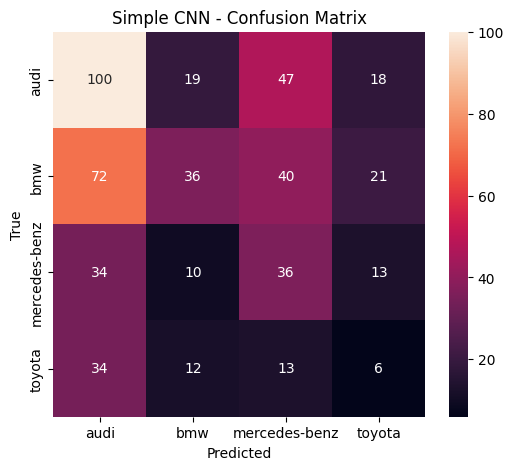


CNN + BN + Dropout Test Accuracy: 0.4755

Classification Report:

               precision    recall  f1-score   support

         audi       0.49      0.83      0.61       184
          bmw       0.49      0.36      0.41       169
mercedes-benz       0.39      0.22      0.28        93
       toyota       0.42      0.17      0.24        65

     accuracy                           0.48       511
    macro avg       0.45      0.39      0.39       511
 weighted avg       0.46      0.48      0.44       511



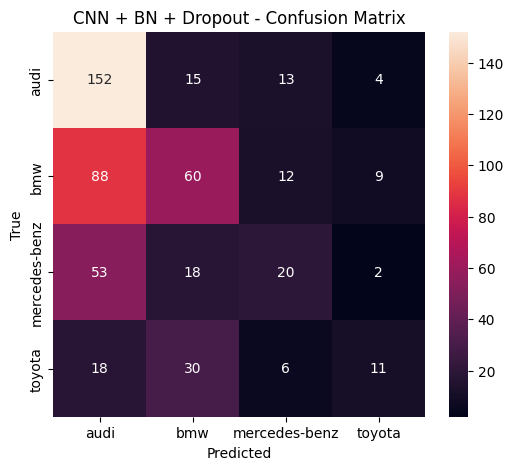


Deep CNN Test Accuracy: 0.3581

Classification Report:

               precision    recall  f1-score   support

         audi       0.40      0.45      0.42       184
          bmw       0.41      0.40      0.41       169
mercedes-benz       0.27      0.27      0.27        93
       toyota       0.17      0.12      0.14        65

     accuracy                           0.36       511
    macro avg       0.31      0.31      0.31       511
 weighted avg       0.35      0.36      0.35       511



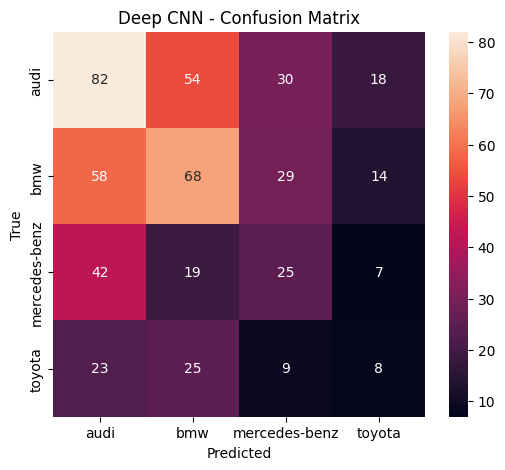


ResNet18 TL Test Accuracy: 0.9393

Classification Report:

               precision    recall  f1-score   support

         audi       0.96      0.95      0.96       184
          bmw       0.95      0.96      0.95       169
mercedes-benz       0.89      0.92      0.91        93
       toyota       0.93      0.88      0.90        65

     accuracy                           0.94       511
    macro avg       0.93      0.93      0.93       511
 weighted avg       0.94      0.94      0.94       511



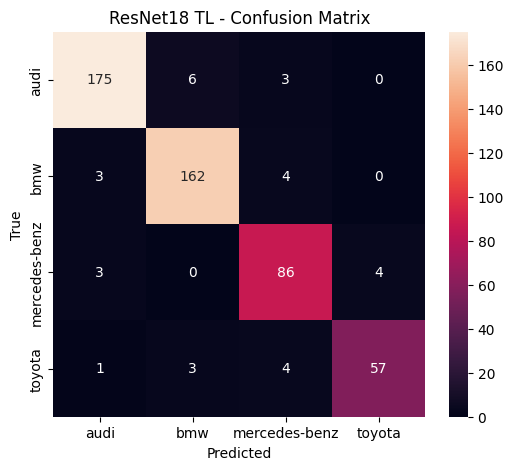

In [ ]:
acc1 = evaluate_on_test(model1, "Simple CNN")
acc2 = evaluate_on_test(model2, "CNN + BN + Dropout")
acc3 = evaluate_on_test(model3, "Deep CNN")
acc_tl = evaluate_on_test(model_tl, "ResNet18 TL")

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Simple CNN",
        "CNN + BN + Dropout",
        "Deep CNN",
        "ResNet18 TL"
    ],
    "Test Accuracy": [
        acc1,
        acc2,
        acc3,
        acc_tl
    ]
})

results.sort_values("Test Accuracy", ascending=False)

,Model,Test Accuracy
3,ResNet18 TL,0.939335
1,CNN + BN + Dropout,0.475538
2,Deep CNN,0.358121
0,Simple CNN,0.348337
